In [1]:
'''
Notebook for developing one-to-one sensitivity analysis figure
'''

__author__ =  'Christian Dewey'
__date__   =  '29 December 2025'
__version__ = '0.1.0'

import os
import sys
from pathlib import Path

from h5py import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pflotranutils.h5_output.calc.cross_section import CrossSection 

# Add shared module to path
sys.path.insert(0, str(Path.cwd().parent))
#sys.path.insert(0, str(Path(__file__).parent / 'shared'))
from processing.pflotran import PflotranProcessor, Region

# Add results directory to path
sys.path.insert(0, str(Path.cwd().parent.parent / 'results'))

# Add model-output directory to path
sys.path.insert(0, str(Path.cwd().parent.parent / 'model-output'))

# Add observation data directory to path
OBS_PATH = str(Path.cwd().parent.parent / 'data/observational')


#### Initialize PFLOTRAN results processor

In [2]:
proc = PflotranProcessor(h5_path='mzt19/2025-12-29/2025-12-29_12-47-14/pflotran-mzt19_2025-12-29_12-47-14.h5', 
                         meander='MZ',
                         perpendicular_axis='x')

In [3]:
PATH_PREFIX = "/Users/christiandewey/Code/dewey-etal_meanders/pflotran/simulations/co2/"
file_location = 'mzt19/pflotran-spin-mzt19_2025-07-15_15-49-12.h5'
file_location = PATH_PREFIX + 'mzt19/2025-12-29/2025-12-29_12-47-14/pflotran-mzt19_2025-12-29_12-47-14_spin.h5'

file_location = "/Users/christiandewey/Code/dewey-etal_meanders/pflotran/simulations/mzt19/2025-12-29/2025-12-29_12-47-14/pflotran-mzt19_2025-12-29_12-47-14.h5"
#if 'mzt' in str.split(file_location,'/')[-2]:
distances = [1.0, 16, 27, 40, 50] #m 
#else:
#    distances = [0.5, 16, 31, 46, 60.]
#depths = [1.7,2.0,2.1,2.4,2.5]

depths = [1.0,1.0,1.0,1.0,1.0]
locs = [(i,d) for i, d in zip(distances,depths)]


components = [
    'pH',
    'Free_Ca++ [M]',
    'Total_HCO3- [M]',
    'Total_Mg++ [M]',
    'Total_SOC(aq) [M]',
    'Total_O2(aq) [M]'
    
]
if '18' in str.split(file_location,'/')[-2]:
    year = 2018
elif '19' in str.split(file_location,'/')[-2]:
    year = 2019

year = '2019'
xsection = CrossSection(file_location,'x')
xsection.get_cells()
components = xsection.component_list
#xsection.print_components() #include='Rate'
times = xsection.times
m_locs = {i:j for i,j in zip(range(1,6),distances)}
results_2D = {d: {} for d in distances}

'''for component in components:
    i=1
    for loc in locs:
        dset = xsection.get_history_at_m_coords(component=component,meter_coords=loc)
        c_dset = dset[:,1]
        locname = m_locs[int(i)]
        results_2D[locname][component]=c_dset
        i=i+1

print(results_2D.keys())
print(results_2D[50]["Total_O2(aq) [M]"])'''

'for component in components:\n    i=1\n    for loc in locs:\n        dset = xsection.get_history_at_m_coords(component=component,meter_coords=loc)\n        c_dset = dset[:,1]\n        locname = m_locs[int(i)]\n        results_2D[locname][component]=c_dset\n        i=i+1\n\nprint(results_2D.keys())\nprint(results_2D[50]["Total_O2(aq) [M]"])'


## Key methods

| Method                                         | Description                      |
|------------------------------------------------|----------------------------------|
| processor.times                                | Array of available time steps    |
| processor.component_list                       | List of available components     |
| processor.get_cells(perp_loc)                  | Set up cross-section at location |
| processor.get_snapshot_all_cells(comp, t)      | Get all cells at time t          |
| processor.get_history_at_m_coords(comp, (x,z)) | Time series at meter coords      |
| processor.plot_at_time(t, comp, ...)           | Plot cross-section               |
| processor.extract_transect_at_time(comp, t)    | Extract 1D transect data         |


Available times: [ 0. 24. 48. 72. 96.] ...

Available components:
Free_Ac- [M]
Free_Al+++ [M]
Free_Ca++ [M]
Free_Cl- [M]
Free_Fe++ [M]
Free_Fe+++ [M]
Free_H+ [M]
Free_H2O [M]
Free_HCO3- [M]
Free_HS- [M]
Free_K+ [M]
Free_Mg++ [M]
Free_N2(aq) [M]
Free_NH3(aq) [M]
Free_NO3- [M]
Free_Na+ [M]
Free_O2(aq) [M]
Free_SO4-- [M]
Free_SOC(aq) [M]
Free_SiO2(aq) [M]
Free_Tracer [M]
Δ         1.0  0.5  0.1
n cells     1  108   26
x-axis is perpendicular
cross-section cells: x-(0, 1), y-(0, 108), z-(0, 26)

Fe++ at t=240.0h, shape: (168, 2)

Fe++ history at (16m, 2m depth): (168, 2)
min value for Free_Fe++ [M]: 0.000E+00
max value for Free_Fe++ [M]: 2.816E-01


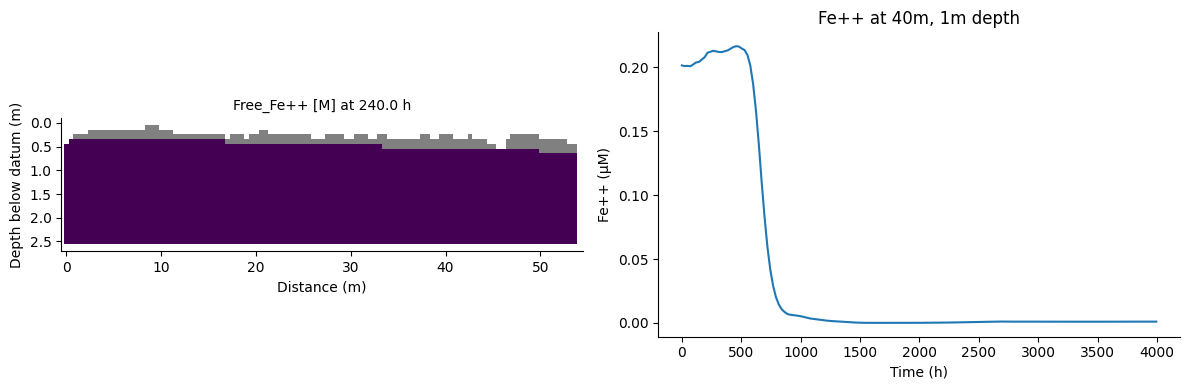

In [4]:
from processing.pflotran import PflotranProcessor

# Initialize with relative path (auto-searches in pflotran/simulations/, etc.)
processor = PflotranProcessor(
    h5_path='mzt19/2025-12-29/2025-12-29_12-47-14/pflotran-mzt19_2025-12-29_12-47-14.h5',
    meander='MZ',
    perpendicular_axis='x'
)

# --- Explore available data ---
# List available times
print("Available times:", processor.times[:5], "...")

# List available components
print("\nAvailable components:")
processor.print_components(include='Free')  # Filter to show only 'Free' species

# --- Extract data ---
# Get cross-section cells
processor.get_cells(perp_loc=0, print_ds=True)

# Get snapshot of a component at a specific time
time_t = processor.times[10]  # Pick a time
fe2_snapshot = processor.get_history_at_m_coords('Free_Fe++ [M]', (40,1))
print(f"\nFe++ at t={time_t}h, shape: {fe2_snapshot.shape}")

# Get time series at a specific location (in meters)
fe2_history = processor.get_history_at_m_coords('Free_Fe++ [M]', meter_coords=(40, 1.0))
print(f"\nFe++ history at (16m, 2m depth): {fe2_history.shape}")

# --- Plotting ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot cross-section at a time
processor.plot_at_time(
    time_t=time_t,
    component='Free_Fe++ [M]',
    show_inactive=False,
    show_unsat=False,
    ax=axes[0],
    unit='uM'
)

# Plot time series
axes[1].plot(fe2_history[:, 0], fe2_history[:, 1] * 1e6)
axes[1].set_xlabel('Time (h)')
axes[1].set_ylabel('Fe++ (μM)')
axes[1].set_title('Fe++ at 40m, 1m depth')

plt.tight_layout()
plt.show()

# --- Thermodynamic calculations ---
# For dG calculations, you need a dict with species concentrations at each time
# Example structure (typically built from extracted data):
# data = {
#     'Free_Fe++ [M]': {time_t: values_array, ...},
#     'Free_HCO3- [M]': {time_t: values_array, ...},
#     'pH': {time_t: values_array, ...},
#     'Free_Ac- [M]': {time_t: values_array, ...},
# }
# dG_fh = processor.calc_fh_dG(data, time_t)


In [5]:
chem_obs_mzt19 = pd.read_csv(OBS_PATH + "/porewater/mz_2019_porewater.csv", parse_dates=['Date'])

chem_obs_mzt18 = pd.read_csv(OBS_PATH + "/porewater/mz_2018_porewater.csv", parse_dates=['Date'])


/var/folders/wn/5cr8mg_n7jjf_kf24wqfck2m0000gn/T/ipykernel_97211/46946533.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  chem_obs_mzt19 = pd.read_csv(OBS_PATH + "/porewater/mz_2019_porewater.csv", parse_dates=['Date'])
/var/folders/wn/5cr8mg_n7jjf_kf24wqfck2m0000gn/T/ipykernel_97211/46946533.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  chem_obs_mzt18 = pd.read_csv(OBS_PATH + "/porewater/mz_2018_porewater.csv", parse_dates=['Date'])


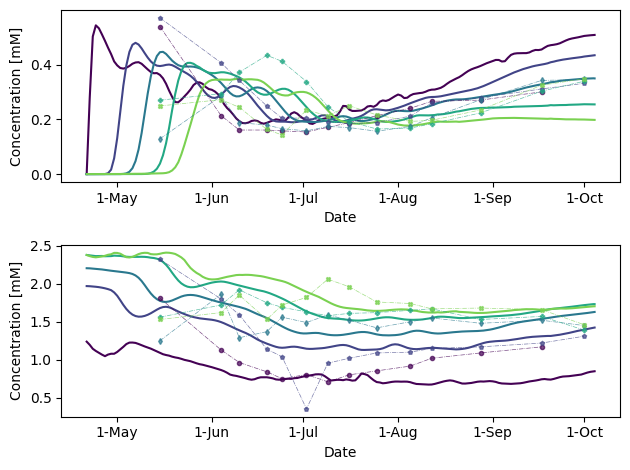

In [6]:
fig, axs = plt.subplots(2,1)
startdate = np.datetime64('2019-04-21')
processor.plot_component_histories(component_name='Total_SO4-- [M]', startdate=startdate, ax=axs[0], unit='mM', chem_obs=chem_obs_mzt19)
processor.plot_component_histories(component_name='Free_Ca++ [M]', startdate=startdate, ax=axs[1], unit='mM', chem_obs=chem_obs_mzt19)
fig.tight_layout()


--- Validation Stats: Total_HCO3- [M] ---
  R²    = 0.809
  RMSE  = 3.92e-01
  Bias  = -1.34e-01
  Slope = 1.084
  n     = 69

--- Validation Stats: Total_HCO3- [M] ---
  R²    = 0.809
  RMSE  = 3.92e-01
  Bias  = -1.34e-01
  Slope = 1.084
  n     = 69

--- Validation Stats: pH ---
  R²    = 0.153
  RMSE  = 3.13e-01
  Bias  = -1.85e-01
  Slope = 0.261
  n     = 63

--- Validation Stats: Total_Ca++ [M] ---
  R²    = 0.554
  RMSE  = 3.28e-01
  Bias  = 1.20e-01
  Slope = 0.923
  n     = 69


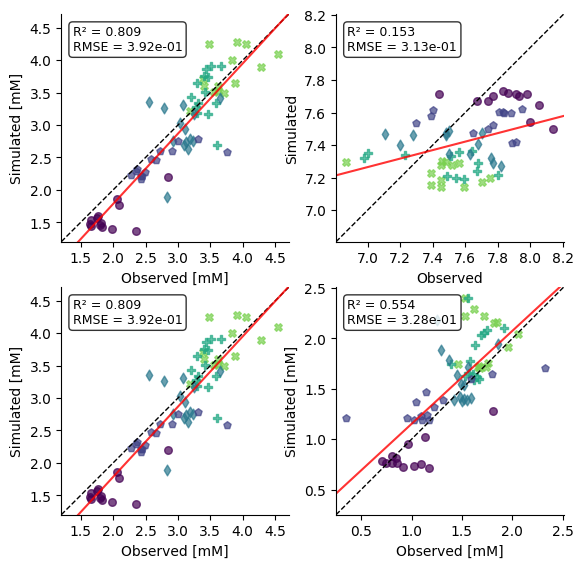

In [9]:
fig, axs = plt.subplots(2,2,figsize=(6.5, 6.5))

ax = axs[0,0]
ax = processor.plot_validation(
    'Total_HCO3- [M]',
    startdate=np.datetime64('2019-05-01'),
    chem_obs=chem_obs_mzt19,
    unit = 'mM',
    ax=ax, 
    show_legend=False
)
ax.set_title('')

ax = axs[1,0]
ax = processor.plot_validation(
    'Total_HCO3- [M]',
    startdate=np.datetime64('2019-05-01'),
    chem_obs=chem_obs_mzt19,
    unit = 'mM',
    ax=ax,
    show_legend=False
)
ax.set_title('')

ax = axs[0,1]
ax = processor.plot_validation(
    'pH',
    startdate=np.datetime64('2019-05-01'),
    chem_obs=chem_obs_mzt19,
    ax=ax,
    show_legend=False
)
ax.set_title('')

ax = axs[1,1]
ax = processor.plot_validation(
    'Total_Ca++ [M]',
    startdate=np.datetime64('2019-05-01'),
    chem_obs=chem_obs_mzt19,
    unit = 'mM',
    ax=ax,
    show_legend=False
)
ax.set_title('')


sns.despine()